# Breast Cancer Classification with a Neural Network


## 1. Imports

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

RANDOM_STATE = 42
%matplotlib inline

## 2. Load the data

In [72]:
df = pd.read_csv("data.csv")

# Drop columns that aren't features (id, and any stray unnamed/empty column
# from a trailing comma in the CSV)
df = df.drop(columns=[c for c in df.columns if "Unnamed" in c or c == "id"], errors="ignore")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [73]:
#check for missing values
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [74]:
#statistics of the dataset
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [75]:
# Check class balance
print("Class balance:")
df["diagnosis"].value_counts()

Class balance:


diagnosis
B    357
M    212
Name: count, dtype: int64

In [76]:
#mean of the features
df.groupby("diagnosis").mean()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
M,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


## 3. Encode target and split features/labels

In [77]:
# diagnosis: M = Malignant, B = Benign  ->  1 / 0
le = LabelEncoder()
y = le.fit_transform(df["diagnosis"])
X = df.drop(columns=["diagnosis"]).values
feature_names = df.drop(columns=["diagnosis"]).columns.tolist()

print("Classes:", list(le.classes_))
print("X shape:", X.shape, "| y shape:", y.shape)

Classes: ['B', 'M']
X shape: (569, 30) | y shape: (569,)


## 4. Train / test split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Train size: 455  |  Test size: 114


## 5. Feature scaling

Neural networks train much better (and often only converge) when inputs are standardized.

In [79]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Build and train the neural network

**Building the neural network**

In [80]:
# Neural Network Model
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(RANDOM_STATE)

In [ ]:
# Define the neural network architecture
model = keras.Sequential([
                          keras.layers.Flatten(input_shape=(30,)), # input layer (1)
                          keras.layers.Dense(20, activation='relu'), # hidden layer (2)
                          keras.layers.Dense(2, activation='sigmoid') # output layer (3)
])

In [82]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [83]:
#training the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    validation_split=0.1,
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7579 - loss: 0.5919 - val_accuracy: 0.8478 - val_loss: 0.5148
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8606 - loss: 0.4420 - val_accuracy: 0.9130 - val_loss: 0.3866
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8973 - loss: 0.3426 - val_accuracy: 0.9130 - val_loss: 0.2989
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9291 - loss: 0.2734 - val_accuracy: 0.9130 - val_loss: 0.2419
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9315 - loss: 0.2260 - val_accuracy: 0.9348 - val_loss: 0.2054
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9364 - loss: 0.1940 - val_accuracy: 0.9348 - val_loss: 0.1823
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9438 - loss: 0.1723 - val_accuracy: 0.9348 - val_loss: 0.1671
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9487 - loss: 0.1565 - val_accuracy: 0.9348 - val_loss

In [84]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test loss: {loss:.4f}  |  Test accuracy: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9737 - loss: 0.1158 
Test loss: 0.1158  |  Test accuracy: 0.9737


**A feedforward network with two hidden layers (32 → 16 neurons), ReLU activations, Adam optimizer, and early stopping.**

In [85]:
model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    alpha=1e-4,                    # L2 regularization
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=15,
    validation_fraction=0.1,
    random_state=RANDOM_STATE,
)

model.fit(X_train_scaled, y_train)
print(f"Stopped after {model.n_iter_} iterations")

Stopped after 45 iterations


## 7. Evaluate on the test set

In [86]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test ROC AUC:  {auc:.4f}")

Test Accuracy: 0.9474
Test ROC AUC:  0.9934


In [87]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

           B       0.93      0.99      0.96        72
           M       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [88]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[71  1]
 [ 5 37]]


## 8. Visualize results

Training loss curve, confusion matrix, and ROC curve.

**Plot training and validation accuracy over epochs for the neural network model**

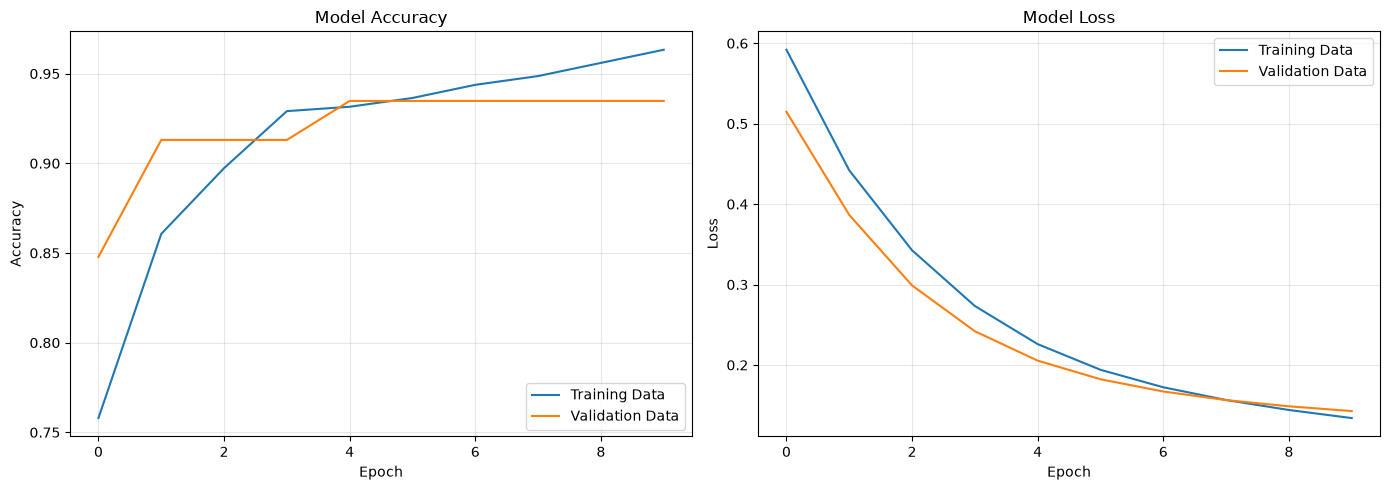

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
axes[0].plot(history.history['accuracy'], label='Training Data')
axes[0].plot(history.history['val_accuracy'], label='Validation Data')
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Loss curve
axes[1].plot(history.history['loss'], label='Training Data')
axes[1].plot(history.history['val_loss'], label='Validation Data')
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("result1.png", dpi=150)
plt.show()

**Plotting the loss curve, confusion matrix and ROC curve for the MLPClassifier model**

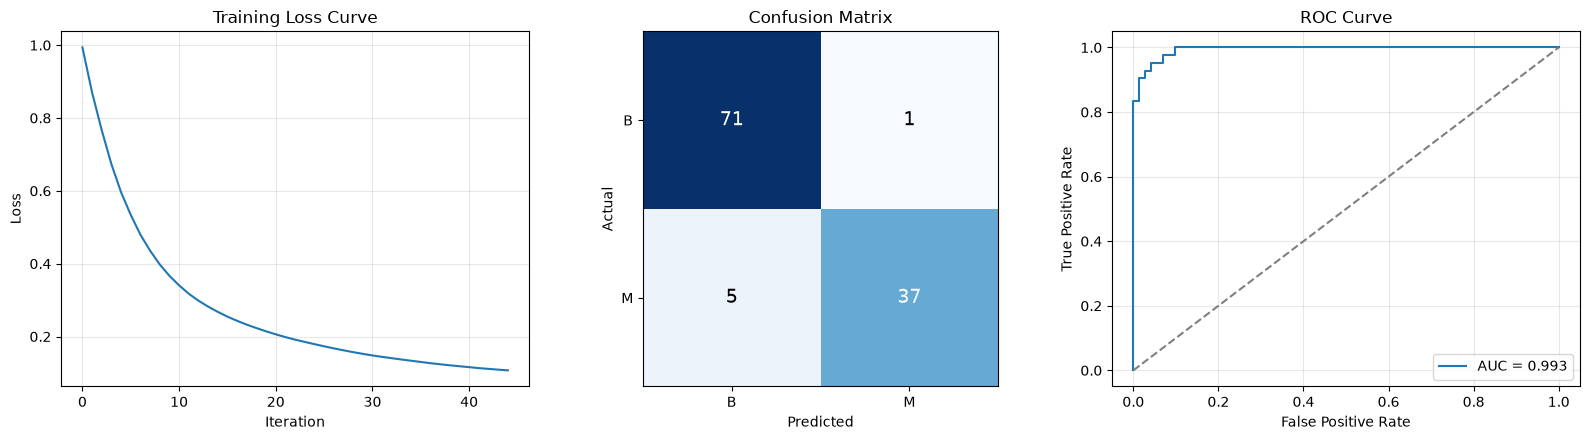

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Loss curve
axes[0].plot(model.loss_curve_)
axes[0].set_title("Training Loss Curve")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# Confusion matrix
axes[1].imshow(cm, cmap="Blues")
axes[1].set_title("Confusion Matrix")
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(le.classes_); axes[1].set_yticklabels(le.classes_)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()

**Building the predictive system**

In [91]:
input_data = (11.76,21.6,74.72,427.9,0.08637,0.04966,0.01657,0.01115,0.1495,0.05888,0.4062,1.21,2.635,28.47,0.005857,0.009758,0.01168,0.007445,0.02406,0.001769,12.98,25.72,82.98,516.5,0.1085,0.08615,0.05523,0.03715,0.2433,0.06563)

# change the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for one data point
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardizing the input data
input_data_std = scaler.transform(input_data_reshaped)

prediction = model.predict(input_data_std)
print("Prediction (0 = Benign, 1 = Malignant):", prediction[0])

prediction_proba = model.predict_proba(input_data_std)
print("Prediction probabilities (Benign, Malignant):", prediction_proba[0])

prediction_nn = model.predict(input_data_std)
print("Neural Network Prediction (0 = Benign, 1 = Malignant):", prediction_nn[0])

Prediction (0 = Benign, 1 = Malignant): 0
Prediction probabilities (Benign, Malignant): [0.98612921 0.01387079]
Neural Network Prediction (0 = Benign, 1 = Malignant): 0
